Veri boyutu: (100000, 20)
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          7500.0          

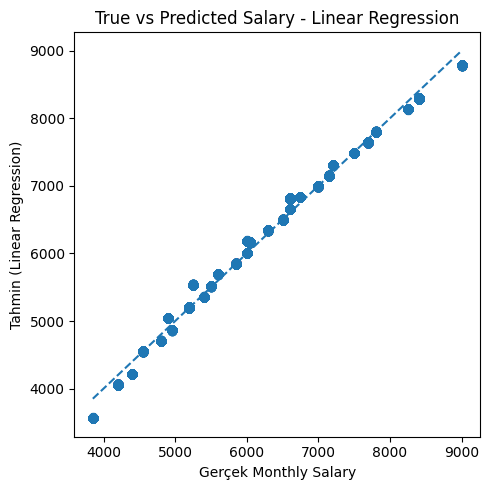

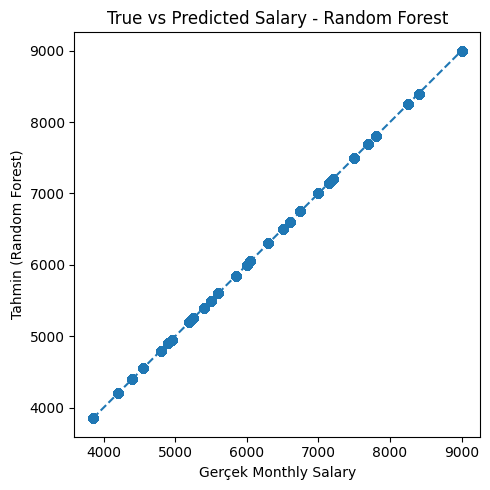

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print(df.head())

target_col = "Monthly_Salary"

drop_cols = ["Employee_ID", "Hire_Date"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100


print("=== MONTHLY SALARY REGRESSION RESULTS ===")
print(f"Linear Regression  -> RMSE: {rmse_lin:.2f}, MAPE: {mape_lin:.2f}%")
print(f"Random Forest      -> RMSE: {rmse_rf:.2f}, MAPE: {mape_rf:.2f}%")

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Linear Regression)")
plt.title("True vs Predicted Salary - Linear Regression")
plt.tight_layout()
plt.show()

# RANDOM FOREST
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Random Forest)")
plt.title("True vs Predicted Salary - Random Forest")
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          7500.0          

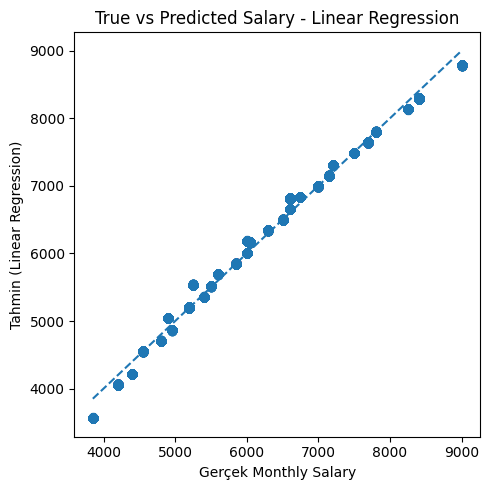

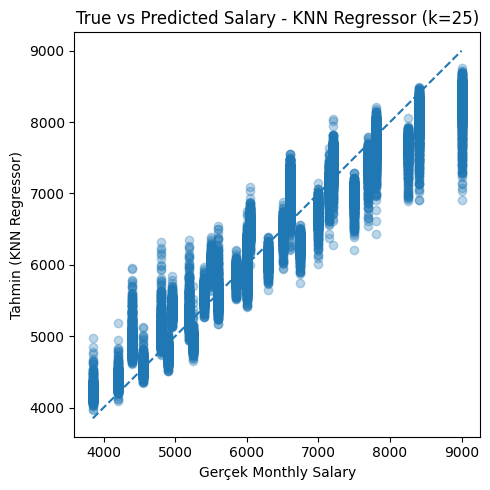

In [ ]:
# 0) KÜTÜPHANELER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print(df.head())

target_col = "Monthly_Salary"

drop_cols = ["Employee_ID", "Hire_Date"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

print("Encode sonrası X şekli:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train boyutu:", X_train.shape, "Test boyutu:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100

knn = KNeighborsRegressor(n_neighbors=25)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn) * 100

print("=== MONTHLY SALARY REGRESSION RESULTS ===")
print(f"Linear Regression -> RMSE: {rmse_lin:.2f}, MAPE: {mape_lin:.2f}%")
print(f"KNN Regressor     -> RMSE: {rmse_knn:.2f}, MAPE: {mape_knn:.2f}%")


plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Linear Regression)")
plt.title("True vs Predicted Salary - Linear Regression")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (KNN Regressor)")
plt.title("True vs Predicted Salary - KNN Regressor (k=25)")
plt.tight_layout()
plt.show()


X shape: (100000, 32)


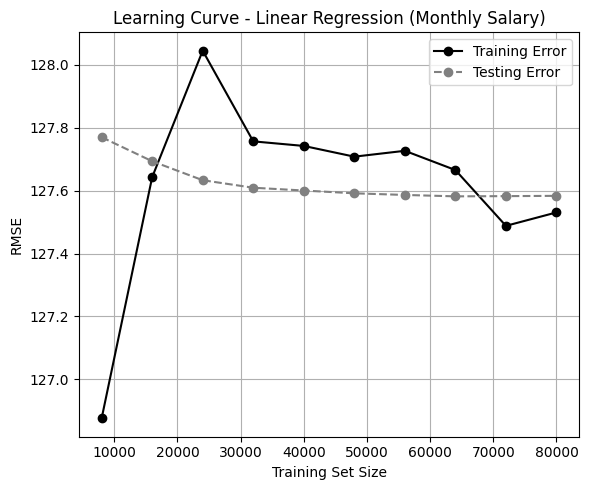

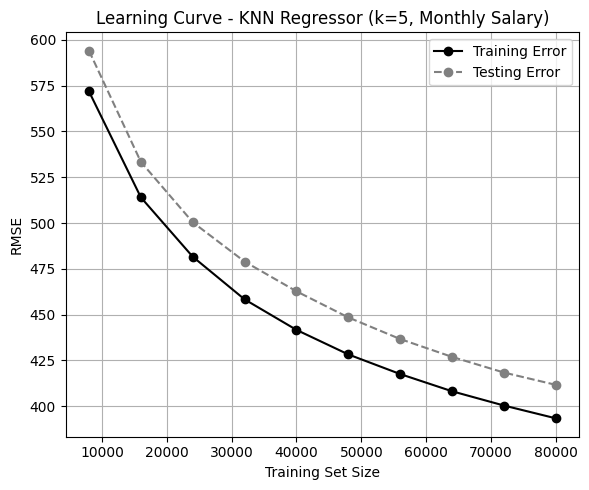

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

drop_cols = ["Employee_ID", "Hire_Date"]
target_col = "Monthly_Salary"

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    test_rmse  = np.sqrt(-test_scores.mean(axis=1))

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_rmse, 'o-', label="Training Error", color='black')
    plt.plot(train_sizes, test_rmse,  'o--', label="Testing Error",  color='gray')
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

lr = LinearRegression()
plot_learning_curve(lr, X, y, "Learning Curve - Linear Regression (Monthly Salary)")

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=25)
)
plot_learning_curve(knn_model, X, y, "Learning Curve - KNN Regressor (k=5, Monthly Salary)")


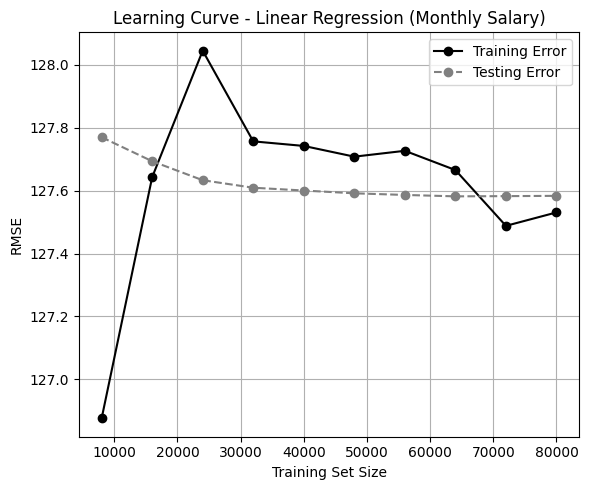

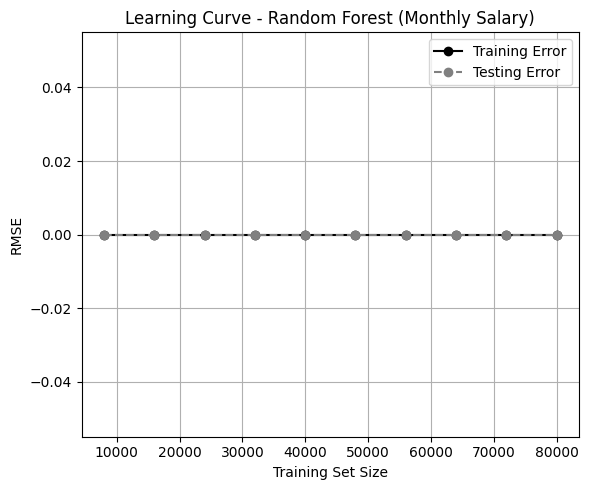

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

drop_cols = ["Employee_ID", "Hire_Date"]
target_col = "Monthly_Salary"

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    test_rmse  = np.sqrt(-test_scores.mean(axis=1))

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_rmse, 'o-', label="Training Error", color='black')
    plt.plot(train_sizes, test_rmse, 'o--', label="Testing Error", color='gray')
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

lr = LinearRegression()
plot_learning_curve(lr, X, y, "Learning Curve - Linear Regression (Monthly Salary)")

rf = RandomForestRegressor(n_estimators=200, random_state=42)
plot_learning_curve(rf, X, y, "Learning Curve - Random Forest (Monthly Salary)")


Veri boyutu: (100000, 20)
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          7500.0          

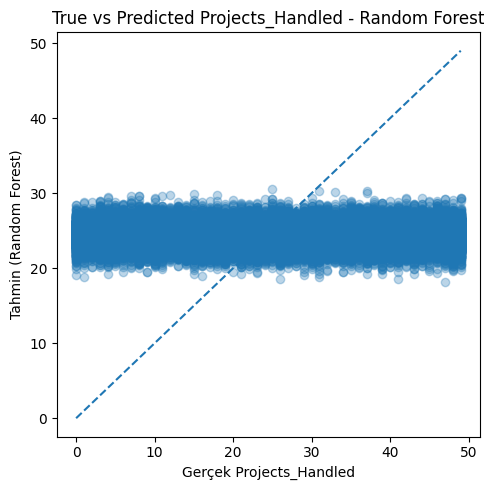


En önemli 10 özellik (Random Forest'in karar vermesinde):
Employee_Satisfaction_Score    0.123713
Training_Hours                 0.106506
Age                            0.088752
Work_Hours_Per_Week            0.085665
Overtime_Hours                 0.077169
Team_Size                      0.073665
Sick_Days                      0.064633
Monthly_Salary                 0.062584
Years_At_Company               0.056813
Remote_Work_Frequency          0.038094
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print(df.head())

target_col = "Projects_Handled"

drop_cols = ["Employee_ID", "Hire_Date"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

print("Encode sonrası X şekli:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train boyutu:", X_train.shape, "Test boyutu:", X_test.shape)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("=== PROJECTS_HANDLED REGRESSION RESULTS (Random Forest) ===")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Gerçek Projects_Handled")
plt.ylabel("Tahmin (Random Forest)")
plt.title("True vs Predicted Projects_Handled - Random Forest")
plt.tight_layout()
plt.show()

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nEn önemli 10 özellik (Random Forest'in karar vermesinde):")
print(importances.head(10))


Veri boyutu: (100000, 20)
Kolonlar: ['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']
One-hot sonrası X şekli: (100000, 32)
Train boyutu: 80000 Test boyutu: 20000

=== KNN CLASSIFIER (k=25) - Performance_Score ===
Doğruluk (Accuracy): 0.943

Confusion Matrix:
[[4001   36    0    0    0]
 [ 542 3277    0    0  283]
 [   0    0 3968    0    0]
 [   0    0    0 3906    0]
 [   0  285    0    0 3702]]

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.99      0.93      4037
           2       0.91      0.80      0.85      4102
           3       1.00      1.00      1.00      3968
           4       1.00      1.00      1.00      3906
           5    

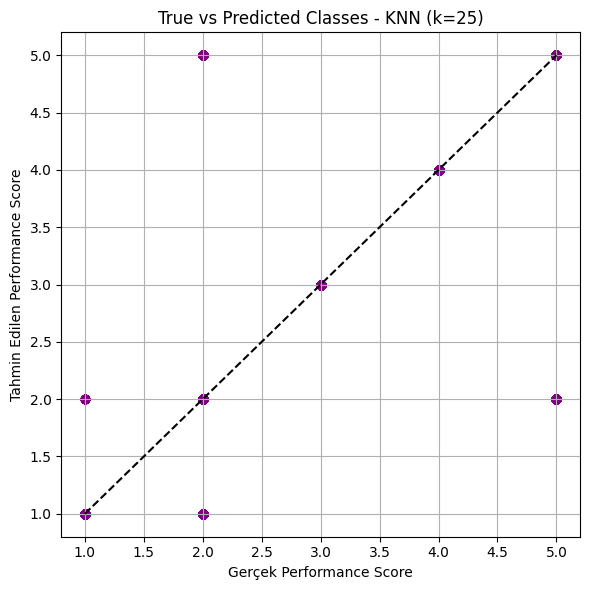

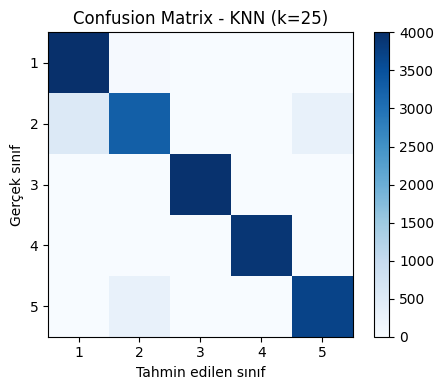

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print("Kolonlar:", df.columns.tolist())


target_col = "Performance_Score"


y = df[target_col].round().astype(int)

drop_cols = ["Employee_ID", "Hire_Date", target_col]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)


X = pd.get_dummies(X, drop_first=True)

print("One-hot sonrası X şekli:", X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train boyutu:", X_train.shape[0], "Test boyutu:", X_test.shape[0])

X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))  # train mean ile doldur
y_train = y_train.fillna(y_train.mode()[0])
y_test  = y_test.fillna(y_test.mode()[0])

knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print("\n=== KNN CLASSIFIER (k=25) - Performance_Score ===")
print(f"Doğruluk (Accuracy): {acc:.3f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="purple")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='black')

plt.xlabel("Gerçek Performance Score")
plt.ylabel("Tahmin Edilen Performance Score")
plt.title("True vs Predicted Classes - KNN (k=25)")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - KNN (k=25)")
plt.xlabel("Tahmin edilen sınıf")
plt.ylabel("Gerçek sınıf")
plt.colorbar()
plt.xticks(ticks=np.arange(cm.shape[1]), labels=sorted(y.unique()))
plt.yticks(ticks=np.arange(cm.shape[0]), labels=sorted(y.unique()))
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
Kolonlar: ['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']
One-hot sonrası X şekli: (100000, 32)
Train boyutu: 67000 Test boyutu: 33000
-----------------------------------------------------------
Random Forest Classifier - Performance_Score (CLASS)
Accuracy: 0.31033333333333335

--- Ağaç 1 ---


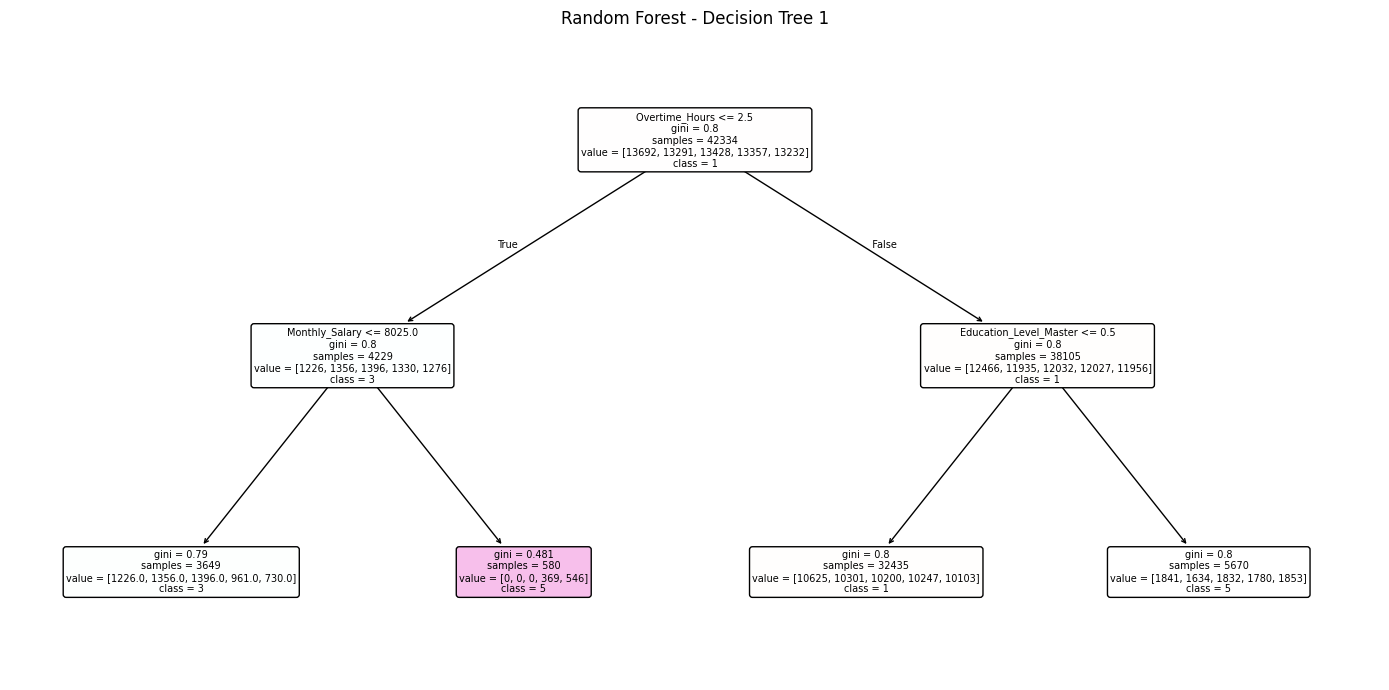


--- Ağaç 2 ---


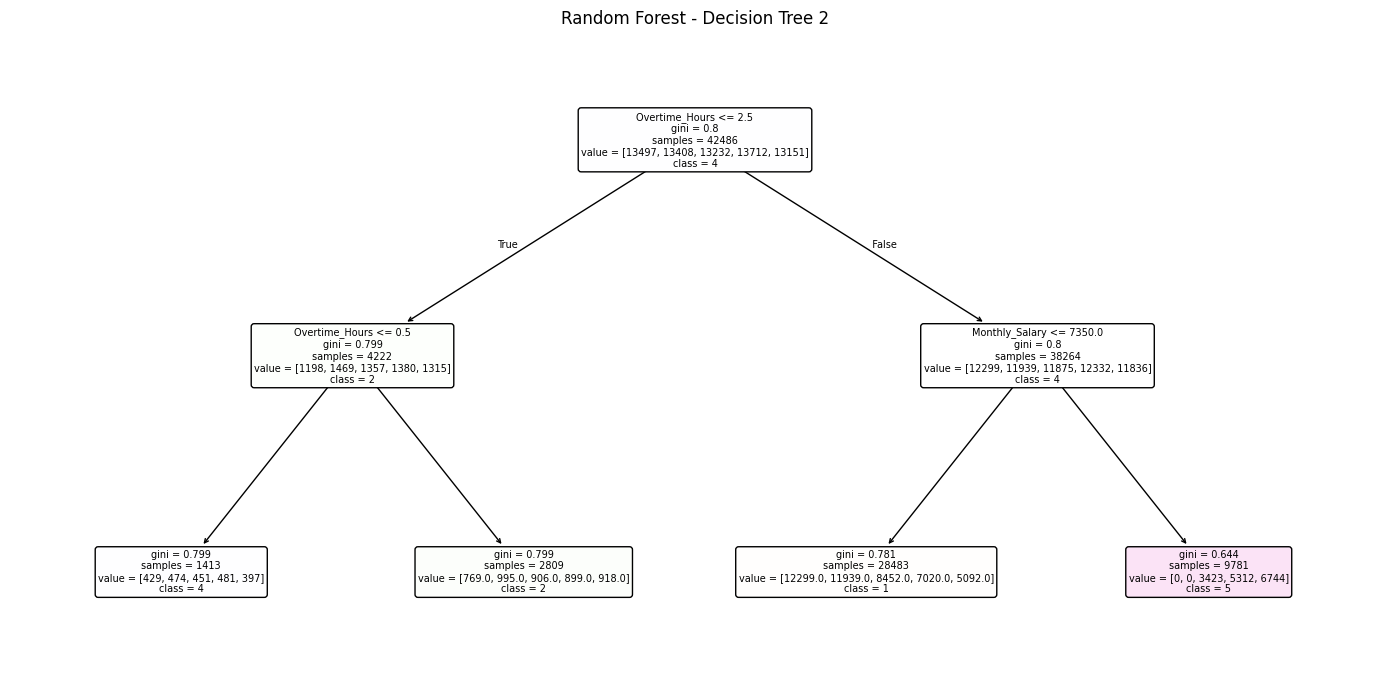


--- Ağaç 3 ---


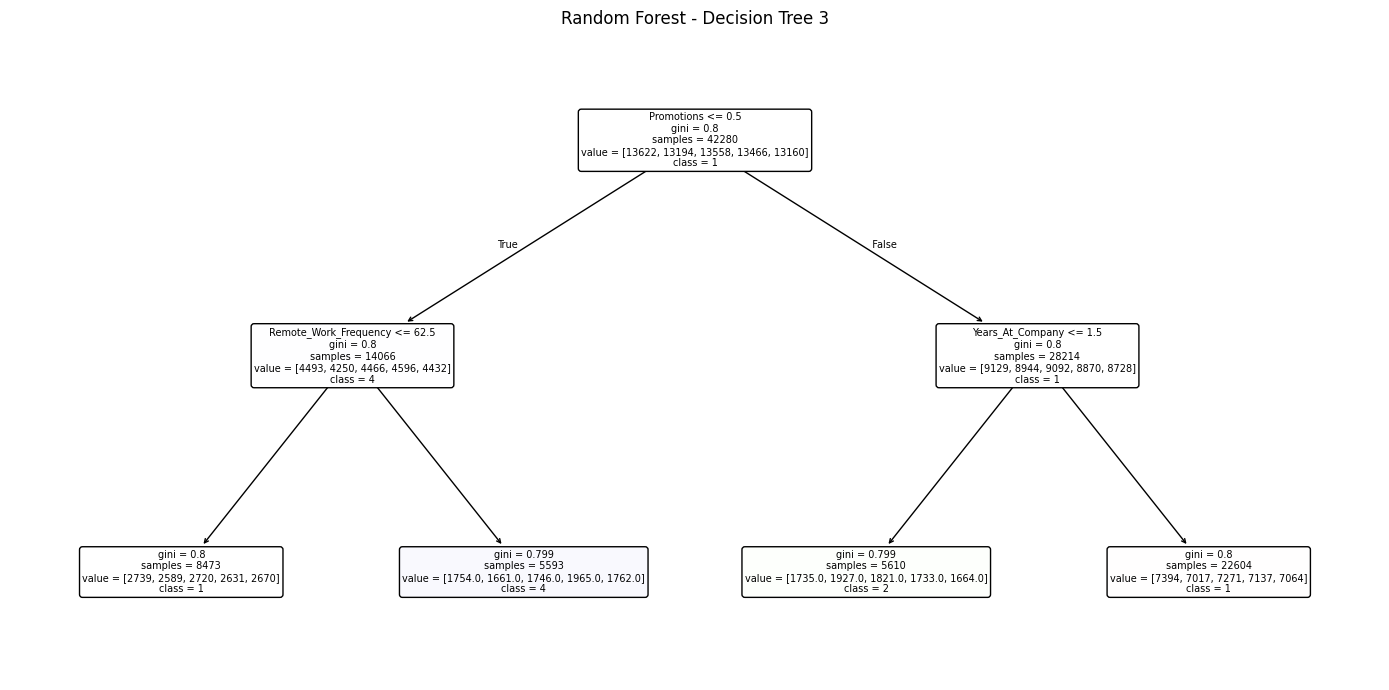

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import tree


df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print("Kolonlar:", df.columns.tolist())


target_col = "Performance_Score"

y = df[target_col].round().astype(int)


drop_cols = ["Employee_ID", "Hire_Date", target_col]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)


X = pd.get_dummies(X, drop_first=True)
print("One-hot sonrası X şekli:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    shuffle=True
)

print("Train boyutu:", X_train.shape[0], "Test boyutu:", X_test.shape[0])

X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))
y_train = y_train.fillna(y_train.mode()[0])
y_test  = y_test.fillna(y_test.mode()[0])


SEED = 42
rfc = RandomForestClassifier(
    n_estimators=3,   
    max_depth=2,     
    random_state=SEED
)

rfc.fit(X_train, y_train)

# Tahmin
y_pred = rfc.predict(X_test)

print("-----------------------------------------------------------")
print("Random Forest Classifier - Performance_Score (CLASS)")
print("Accuracy:", accuracy_score(y_test, y_pred))

features = X.columns.values
# sınıf isimleri (Performance_Score 1–5)
classes = [str(c) for c in sorted(y.unique())]

for idx, estimator in enumerate(rfc.estimators_):
    print(f"\n--- Ağaç {idx+1} ---")
    plt.figure(figsize=(14, 7))
    tree.plot_tree(
        estimator,
        feature_names=features,
        class_names=classes,
        fontsize=7,
        filled=True,
        rounded=True
    )
    plt.title(f"Random Forest - Decision Tree {idx+1}")
    plt.tight_layout()
    plt.show()


Random Forest Accuracy: 0.7686666666666667


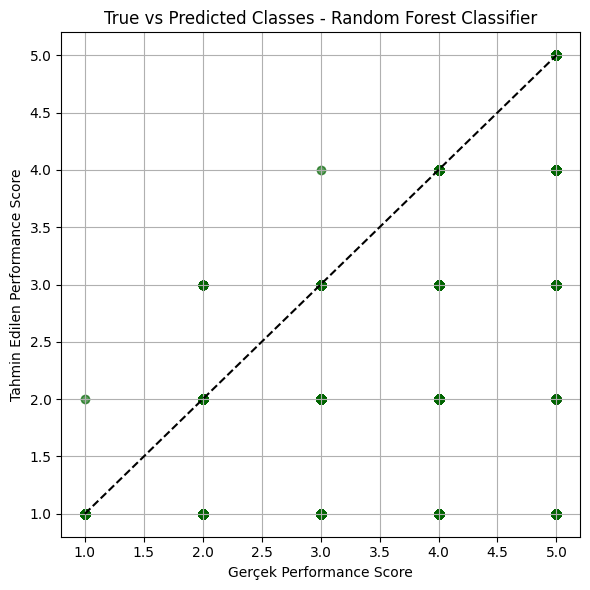

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")


target_col = "Performance_Score"
y = df[target_col].round().astype(int)

drop_cols = ["Employee_ID", "Hire_Date", target_col]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Fill NA
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))


rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Tahmin
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", acc)


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="darkgreen")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "--", color="black")

plt.xlabel("Gerçek Performance Score")
plt.ylabel("Tahmin Edilen Performance Score")
plt.title("True vs Predicted Classes - Random Forest Classifier")
plt.grid(True)
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
İlk 5 satır:
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          750

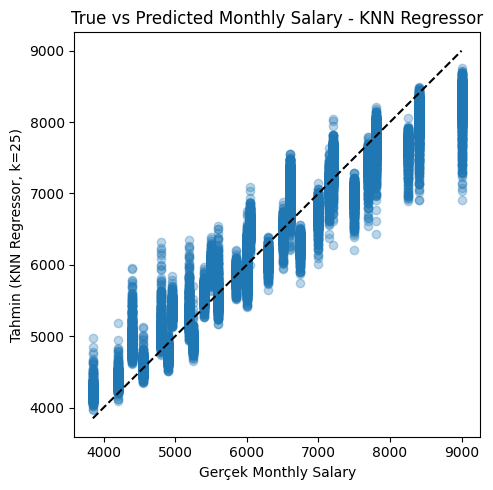

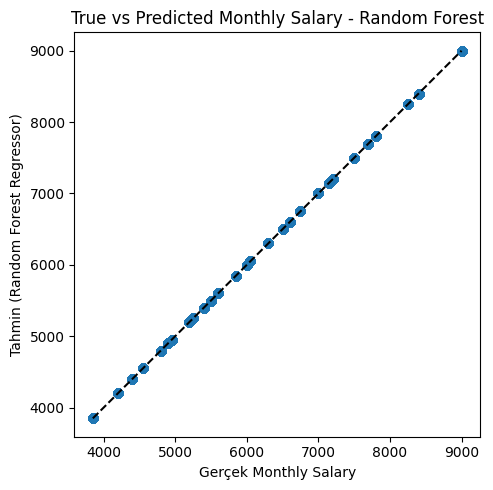

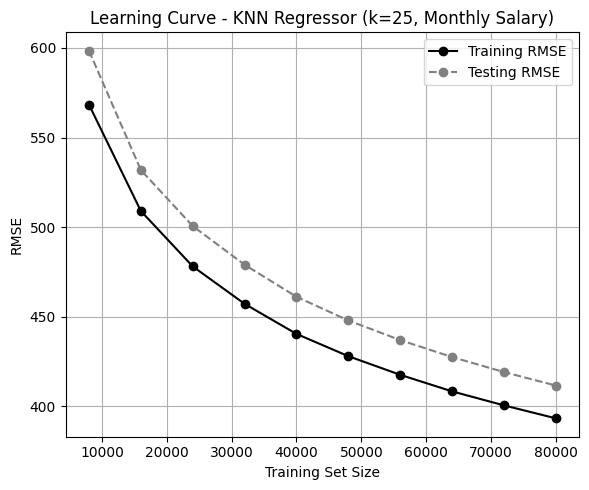

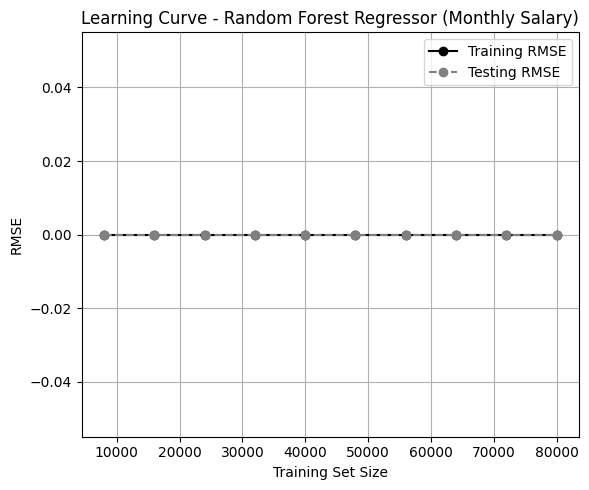

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import make_pipeline

df = pd.read_csv(r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv")

print("Veri boyutu:", df.shape)
print("İlk 5 satır:")
print(df.head())


target_col = "Monthly_Salary"
drop_cols = ["Employee_ID", "Hire_Date"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

print("\nEncode sonrası X şekli:", X.shape)
print("Toplam feature sayısı:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain boyutu:", X_train.shape[0])
print("Test boyutu :", X_test.shape[0])


knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=25)
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

knn_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))

mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
mape_rf  = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print("\n================= REGRESSION RESULTS (Monthly_Salary) =================")
print(f"KNN Regressor (k=25)   -> RMSE: {rmse_knn:.2f}, MAPE: {mape_knn:.2f}%")
print(f"Random Forest Regressor-> RMSE: {rmse_rf:.2f},  MAPE: {mape_rf:.2f}%")


plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (KNN Regressor, k=25)")
plt.title("True vs Predicted Monthly Salary - KNN Regressor")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Random Forest Regressor)")
plt.title("True vs Predicted Monthly Salary - Random Forest")
plt.tight_layout()
plt.show()



def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    test_rmse  = np.sqrt(-test_scores.mean(axis=1))

    plt.figure(figsize=(6,5))
    plt.plot(train_sizes, train_rmse, 'o-', label="Training RMSE", color='black')
    plt.plot(train_sizes, test_rmse,  'o--', label="Testing RMSE",  color='gray')
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_learning_curve(
    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=25)),
    X, y,
    "Learning Curve - KNN Regressor (k=25, Monthly Salary)"
)

plot_learning_curve(
    RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    X, y,
    "Learning Curve - Random Forest Regressor (Monthly Salary)"
)


Veri boyutu: (100000, 20)
Kolonlar: ['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']

Monthly_Salary median: 6500.0

X şekli (drop sonrası): (100000, 17)
One-hot sonrası X şekli: (100000, 32)

Train boyutu: 67000
Test boyutu : 33000

---------------------------------
Intercept :
[-25.71858429]

---------------------------------
Score (model.score) :
1.0

Accuracy (accuracy_score): 1.0


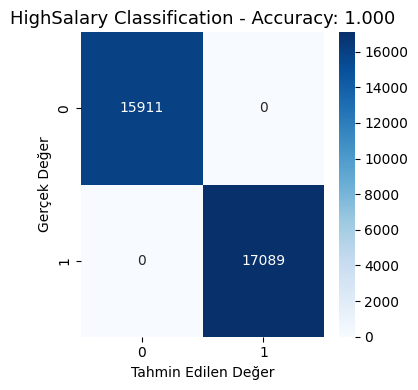

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix as cm
from sklearn.model_selection import train_test_split


df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Veri boyutu:", df.shape)
print("Kolonlar:", df.columns.tolist())


salary_median = df["Monthly_Salary"].median()
print("\nMonthly_Salary median:", salary_median)

df["HighSalary"] = (df["Monthly_Salary"] >= salary_median).astype(int)

# 
y = df["HighSalary"]


drop_cols = ["Employee_ID", "Hire_Date", "Monthly_Salary", "HighSalary"]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)

print("\nX şekli (drop sonrası):", X.shape)


X = pd.get_dummies(X, drop_first=True)
print("One-hot sonrası X şekli:", X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    shuffle=True
)

print("\nTrain boyutu:", X_train.shape[0])
print("Test boyutu :", X_test.shape[0])

X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))
y_train = y_train.fillna(y_train.mode()[0])
y_test  = y_test.fillna(y_test.mode()[0])


model = LogisticRegression(
    solver='liblinear',  
    random_state=42
)

model.fit(X_train, y_train)

print("\n---------------------------------")
print("Intercept :")
print(model.intercept_)

print("\n---------------------------------")
print("Score (model.score) :")
print(model.score(X_test, y_test))

predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)
cm1 = cm(y_test, predictions)

print("\nAccuracy (accuracy_score):", score)

plt.figure(figsize=(4,4))
sns.heatmap(cm1, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Gerçek Değer')
plt.title('HighSalary Classification - Accuracy: {0:.3f}'.format(score), size=13)
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          7500.0          

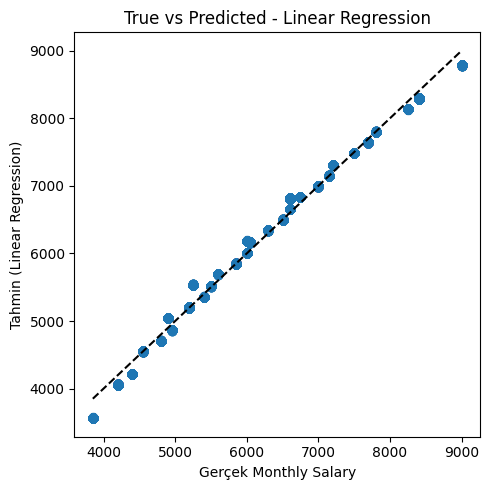

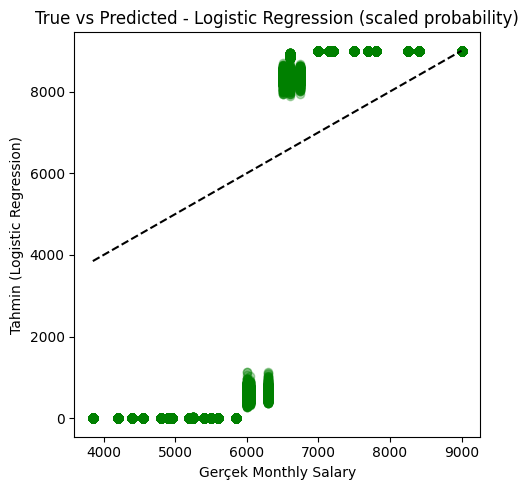

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Veri boyutu:", df.shape)
print(df.head())


target_col = "Monthly_Salary"
drop_cols = ["Employee_ID", "Hire_Date"]   

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)
print("Encode sonrası X şekli:", X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))


def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = safe_mape(y_test, y_pred_lin)


median_salary = y_train.median()
y_train_cls = (y_train >= median_salary).astype(int)
y_test_cls  = (y_test >= median_salary).astype(int)

log_reg = LogisticRegression(solver="liblinear")
log_reg.fit(X_train, y_train_cls)


max_salary = y.max()
y_pred_log_proba = log_reg.predict_proba(X_test)[:, 1]
y_pred_log = y_pred_log_proba * max_salary

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mape_log = safe_mape(y_test, y_pred_log)


print("\n================= REGRESSION RESULTS =================")
print("Target attribute: Monthly_Salary")
print("Train/Test split: 80% / 20%\n")

print(f"Linear Regression   -> RMSE: {rmse_lin:.2f}, MAPE: {mape_lin:.2f}%")
print(f"Logistic Regression -> RMSE: {rmse_log:.2f}, MAPE: {mape_log:.2f}%")


# ---- LINEAR ----
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--", color="black")
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Linear Regression)")
plt.title("True vs Predicted - Linear Regression")
plt.tight_layout()
plt.show()

# ---- LOGISTIC ----
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_log, alpha=0.3, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--", color="black")
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Logistic Regression)")
plt.title("True vs Predicted - Logistic Regression (scaled probability)")
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
Monthly_Salary median: 6500.0
X şekli: (100000, 33)
Accuracy: 0.9723


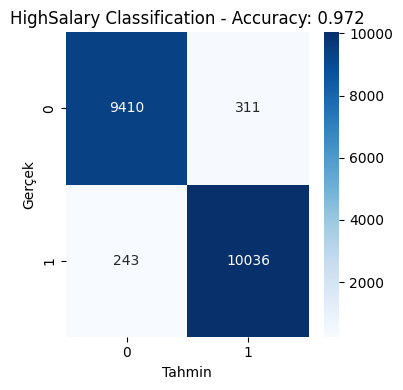

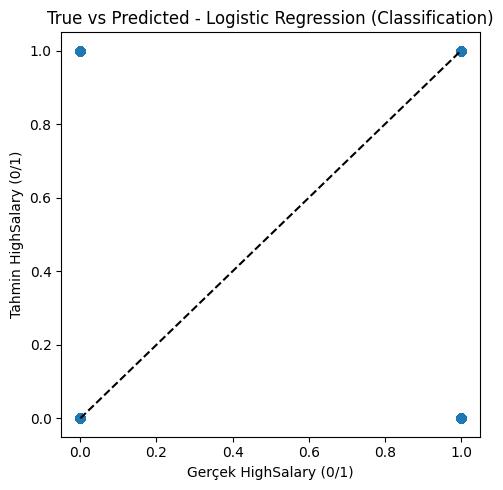

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix as cm
from sklearn.model_selection import train_test_split

# 1) VERİYİ OKU
df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Veri boyutu:", df.shape)

salary_median = df["Monthly_Salary"].median()
print("Monthly_Salary median:", salary_median)

df["HighSalary"] = (df["Monthly_Salary"] >= salary_median).astype(int)
y = df["HighSalary"]

drop_cols = ["Employee_ID", "Hire_Date", "HighSalary"]  
X = df.drop(columns=drop_cols)

X = pd.get_dummies(X, drop_first=True)
print("X şekli:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Eksik değer doldur
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test  = X_test.fillna(X_train.mean(numeric_only=True))

model = LogisticRegression(
    solver="liblinear",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm1 = cm(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm1, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title(f"HighSalary Classification - Accuracy: {acc:.3f}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,1],[0,1],"--",color="black")
plt.xlabel("Gerçek HighSalary (0/1)")
plt.ylabel("Tahmin HighSalary (0/1)")
plt.title("True vs Predicted - Logistic Regression (Classification)")
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
İlk 5 satır:
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          750

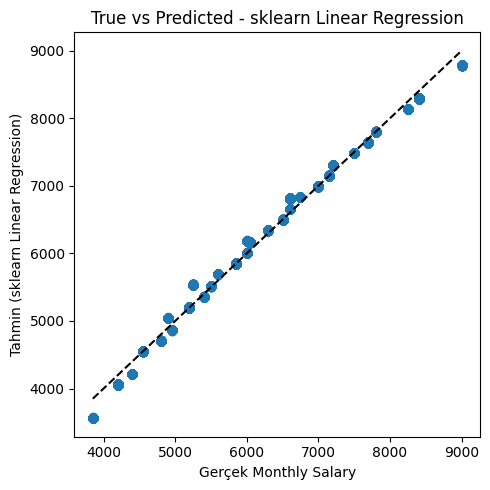

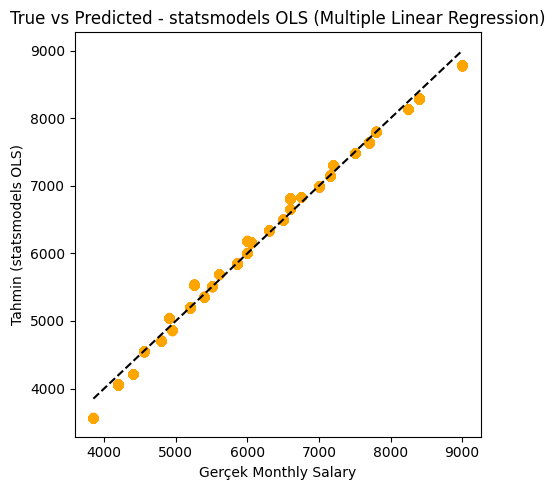

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Veri boyutu:", df.shape)
print("İlk 5 satır:")
print(df.head())


target_col = "Monthly_Salary"
y = df[target_col].astype(float)

df["Hire_Date"] = pd.to_datetime(df["Hire_Date"])
df["Hire_Date_Ordinal"] = df["Hire_Date"].map(pd.Timestamp.toordinal)

drop_cols = ["Employee_ID", "Hire_Date", target_col]
X_raw = df.drop(columns=drop_cols)

# One-hot encoding
X = pd.get_dummies(X_raw, drop_first=True)

# Eksik değer doldur
X = X.fillna(X.mean(numeric_only=True))

print("\nFeature matrisi şekli:", X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain boyutu:", X_train.shape[0])
print("Test boyutu :", X_test.shape[0])


def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = safe_mape(y_test, y_pred_lin)

print("\n=== SKLEARN LINEAR REGRESSION ===")
print("Intercept:", lin_reg.intercept_)
print("İlk 10 coefficient:", lin_reg.coef_[:10])


X_train_sm = X_train.astype(float)
X_test_sm  = X_test.astype(float)

X_train_sm = sm.add_constant(X_train_sm)
X_test_sm  = sm.add_constant(X_test_sm, has_constant='add')

ols_model = sm.OLS(y_train.astype(float), X_train_sm).fit()
y_pred_ols = ols_model.predict(X_test_sm)

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mape_ols = safe_mape(y_test, y_pred_ols)

print("\n=== STATSMODELS OLS (MULTIPLE LINEAR REGRESSION) ===")
print(ols_model.summary())

print("\n================= REGRESSION RESULTS (Monthly_Salary) =================")
print("Target attribute : Monthly_Salary")
print("Train/Test split : 80% / 20%\n")

print(f"sklearn Linear Regression -> RMSE: {rmse_lin:.2f}, MAPE: {mape_lin:.2f}%")
print(f"statsmodels OLS          -> RMSE: {rmse_ols:.2f}, MAPE: {mape_ols:.2f}%")



# --- SKLEARN LINEAR ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (sklearn Linear Regression)")
plt.title("True vs Predicted - sklearn Linear Regression")
plt.tight_layout()
plt.show()

# --- STATSMODELS OLS ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_ols, alpha=0.3, color="orange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (statsmodels OLS)")
plt.title("True vs Predicted - statsmodels OLS (Multiple Linear Regression)")
plt.tight_layout()
plt.show()


Veri boyutu: (100000, 20)
İlk 5 satır:
   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          750

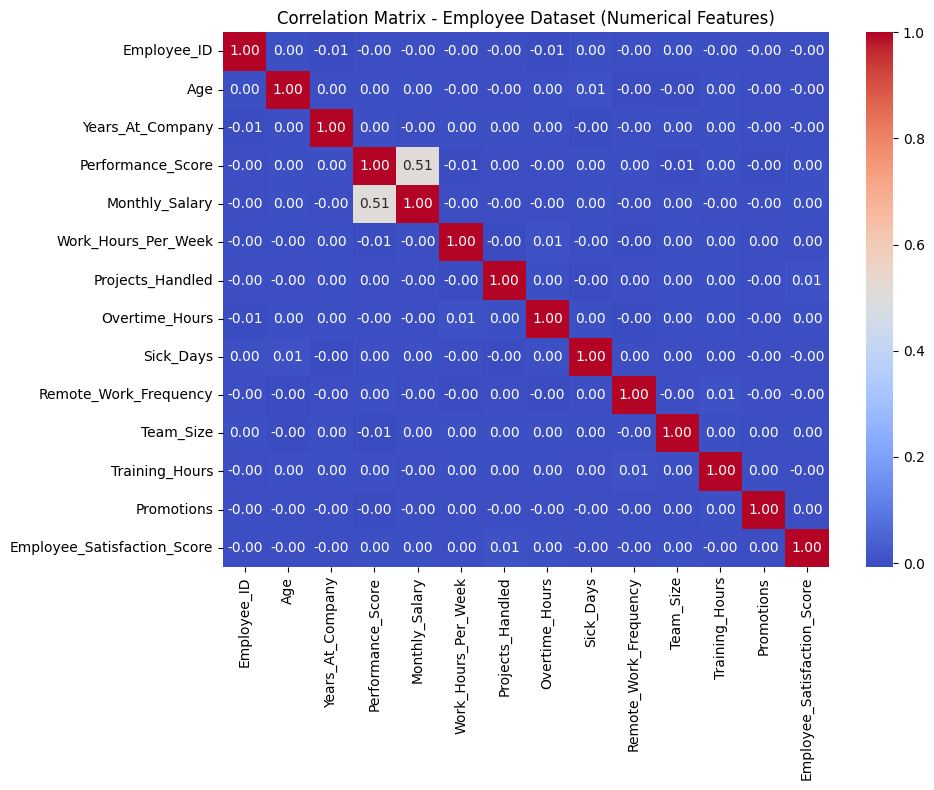


Feature matrisi şekli: (100000, 32)

Train boyutu: 80000
Test boyutu : 20000

================= REGRESSION RESULTS (Monthly_Salary) =================
Target attribute : Monthly_Salary
Train/Test split : 80% / 20%

Linear Regression (Pipeline) -> RMSE: 127.22, MAPE: 1.62%
KNN Regressor (k=25)        -> RMSE: 413.50, MAPE: 5.29%


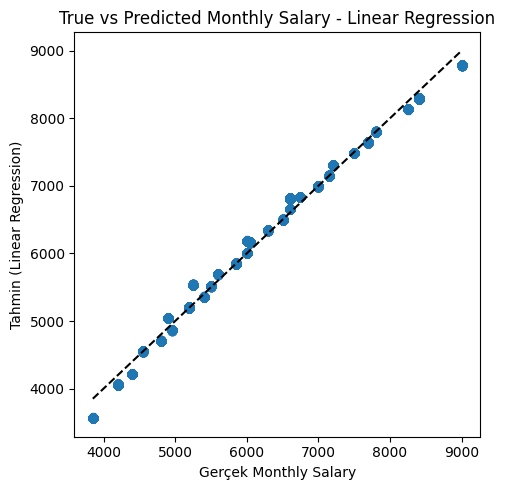

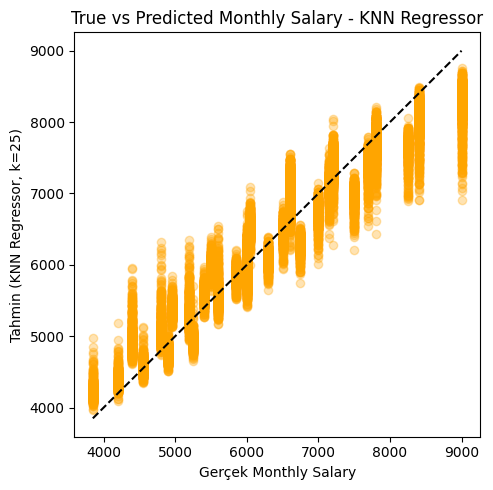

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv(
    r"C:\Users\eren_\Downloads\archive (4)\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Veri boyutu:", df.shape)
print("İlk 5 satır:")
print(df.head())


numerical_data = df.select_dtypes(include=["int64", "float64", "int32", "float32"])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Employee Dataset (Numerical Features)")
plt.tight_layout()
plt.show()


target_col = "Monthly_Salary"
y = df[target_col]

# - Employee_ID: id
drop_cols = ["Employee_ID", "Hire_Date", target_col]
X_raw = df.drop(columns=drop_cols)

X = pd.get_dummies(X_raw, drop_first=True)

X = X.fillna(X.mean(numeric_only=True))

print("\nFeature matrisi şekli:", X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # %20 test
    random_state=42,
    shuffle=True
)

print("\nTrain boyutu:", X_train.shape[0])
print("Test boyutu :", X_test.shape[0])


def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


lin_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

lin_pipeline.fit(X_train, y_train)
y_pred_lin = lin_pipeline.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = safe_mape(y_test, y_pred_lin)


knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", KNeighborsRegressor(n_neighbors=25))
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = safe_mape(y_test, y_pred_knn)


print("\n================= REGRESSION RESULTS (Monthly_Salary) =================")
print("Target attribute : Monthly_Salary")
print("Train/Test split : 80% / 20%\n")

print(f"Linear Regression (Pipeline) -> RMSE: {rmse_lin:.2f}, MAPE: {mape_lin:.2f}%")
print(f"KNN Regressor (k=25)        -> RMSE: {rmse_knn:.2f}, MAPE: {mape_knn:.2f}%")


plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (Linear Regression)")
plt.title("True vs Predicted Monthly Salary - Linear Regression")
plt.tight_layout()
plt.show()


plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_knn, alpha=0.3, color="orange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Gerçek Monthly Salary")
plt.ylabel("Tahmin (KNN Regressor, k=25)")
plt.title("True vs Predicted Monthly Salary - KNN Regressor")
plt.tight_layout()
plt.show()
